# 02 — Feature Selection Screening (play_type)

Statistical screening pass for the **play-type** classifier (`pass` vs `run`).
Operates on the full candidate feature set in `data/interim/features_full.parquet`
*before* the automated selection pipeline (`src/selection/`) narrows it down.

Feature groups are imported from `src.selection.shared.feature_schema` — the
single source of truth — so this notebook never hardcodes column names.

**Methods**
1. Correlation analysis (Spearman) + Variance Inflation Factor (VIF)
2. Mutual information — all features vs target
3. ANOVA F-test — numerical features
4. Chi-square test — categorical features

## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Notebook runs from notebooks/; put repo root on the path so we can import
# the selection feature schema and resolve its repo-relative data paths.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.selection.shared.feature_schema import (
    FEATURES_FULL_PATH,
    TARGET_CLF,
    CAT_FEATURES,
    RAW_NUMERIC,
    ROLLING_FEATURES,
    ENGINEERED_FEATURES,
    ENCODED_FEATURES,
    ALL_NUMERIC,
    CHI2_FEATURES,
    CHI2_BINARY_FEATURES,
    CHI2_DISCRETE_FEATURES,
    SEED,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_rows", 120)
print("Imports OK")

Imports OK


## 1. Data load & target encoding

`play_type` is a string (`pass`/`run`) in the interim parquet. Encode it as
`pass=1 / run=0` for the screening tests (the modeling parquet stores it the
same way).

In [2]:
df = pd.read_parquet(REPO_ROOT / FEATURES_FULL_PATH)
print(f"Raw shape: {df.shape}  |  Seasons: {sorted(df['season'].unique())}")

# Target: pass=1, run=0
y = (df[TARGET_CLF] == "pass").astype(int)
print(f"\nClass balance ({TARGET_CLF}):")
print(y.value_counts().rename({1: "pass", 0: "run"}).to_string())
print(f"pass rate: {y.mean():.3f}")

Raw shape: (276286, 54)  |  Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Class balance (play_type):
pass    160936
run     115350
pass rate: 0.582


In [3]:
# Feature-group sanity check against the schema
print(f"Numeric features (ALL_NUMERIC):   {len(ALL_NUMERIC)}")
print(f"Categorical features (CAT_FEATURES): {len(CAT_FEATURES)}")
print(f"Chi-square features (CHI2_FEATURES): {len(CHI2_FEATURES)}")

missing = [c for c in ALL_NUMERIC + CAT_FEATURES if c not in df.columns]
assert not missing, f"schema columns absent from parquet: {missing}"
print("\nAll schema features present in parquet.")

Numeric features (ALL_NUMERIC):   30
Categorical features (CAT_FEATURES): 6
Chi-square features (CHI2_FEATURES): 12

All schema features present in parquet.


In [4]:
# Numeric feature matrix (median-imputed for the multivariate tests below).
# Screening only — median imputation here does not touch the modeling pipeline.
# astype(float) collapses any nullable extension dtypes to a plain numpy
# float matrix (statsmodels/sklearn need .values to be a numeric ndarray).
X_num = df[ALL_NUMERIC].apply(pd.to_numeric, errors="coerce").astype("float64")
na_frac = X_num.isna().mean().sort_values(ascending=False)
print("Numeric NaN fraction (top 10):")
print(na_frac.head(10).to_string())

X_num_imp = X_num.fillna(X_num.median())

Numeric NaN fraction (top 10):
def_pass_yds_allowed_L3    0.05781
off_rush_yds_L3            0.05781
def_pass_epa_L3            0.05781
def_rush_epa_L3            0.05781
def_epa_L3                 0.05781
def_rush_yds_allowed_L3    0.05781
off_pass_epa_L3            0.05781
off_rush_epa_L3            0.05781
off_epa_L3                 0.05781
off_pass_yds_L3            0.05781


## 2. Correlation analysis + VIF

Spearman ρ (rank correlation — robust to non-linearity and outliers) across the
numeric features. High pairwise |ρ| flags redundancy; VIF quantifies how much a
feature is linearly explained by *all* the others.

Rule of thumb: **VIF > 10** = severe multicollinearity, **VIF > 5** = moderate.

In [5]:
corr = X_num_imp.corr(method="spearman")

# Highly correlated pairs (|rho| >= 0.7)
pairs = (
    corr.where(~np.tril(np.ones(corr.shape, dtype=bool)))
    .stack()
    .rename("rho")
    .reset_index()
    .rename(columns={"level_0": "feat_a", "level_1": "feat_b"})
)
pairs["abs_rho"] = pairs["rho"].abs()
high_corr = pairs[pairs["abs_rho"] >= 0.7].sort_values("abs_rho", ascending=False)

print(f"Feature pairs with |Spearman rho| >= 0.7:  {len(high_corr)}")
high_corr[["feat_a", "feat_b", "rho"]].reset_index(drop=True)

Feature pairs with |Spearman rho| >= 0.7:  13


,feat_a,feat_b,rho
0,score_differential,time_adjusted_score_diff,0.980065
1,qtr,game_seconds_remaining,-0.966823
2,off_epa_L3,off_pass_epa_L3,0.901474
3,def_epa_L3,def_pass_epa_L3,0.894885
4,off_pass_yds_L3,off_pass_epa_L3,0.834977
5,def_pass_yds_allowed_L3,def_pass_epa_L3,0.815794
6,defenders_in_box,box_advantage,-0.763718
7,off_pass_yds_L3,off_epa_L3,0.758323
8,def_pass_yds_allowed_L3,def_epa_L3,0.745869
9,temp,is_indoor,-0.726376


In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF on standardized, imputed numeric matrix (constant added for the intercept).
X_vif = add_constant(X_num_imp, has_constant="add")
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)

def vif_flag(v):
    return "severe (>10)" if v > 10 else "moderate (>5)" if v > 5 else "ok"

vif["flag"] = vif["VIF"].apply(vif_flag)

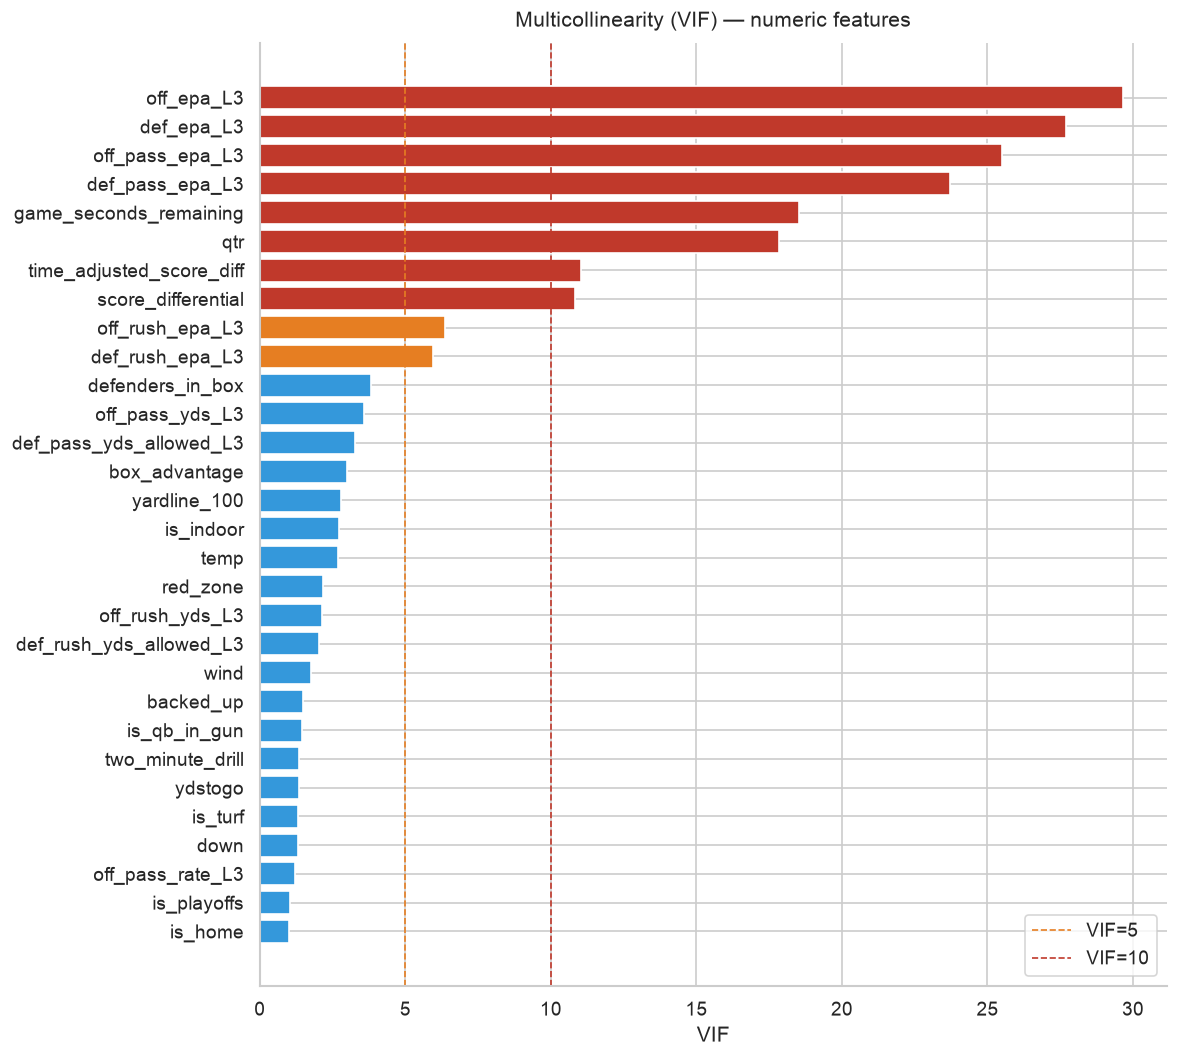

In [7]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = vif["VIF"].apply(lambda v: "#c0392b" if v > 10 else "#e67e22" if v > 5 else "#3498db")
ax.barh(vif["feature"], vif["VIF"], color=colors)
ax.axvline(5, ls="--", c="#e67e22", lw=1, label="VIF=5")
ax.axvline(10, ls="--", c="#c0392b", lw=1, label="VIF=10")
ax.invert_yaxis()
ax.set_xlabel("VIF")
ax.set_title("Multicollinearity (VIF) — numeric features", pad=10)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Mutual information — all features

MI captures *any* dependency (linear or not) between each feature and the target,
in nats. `mutual_info_classif` handles numeric and discrete inputs; discrete /
binary encoded features are flagged so MI uses the right estimator.

Categorical string features are label-encoded and marked discrete. Encoded
binaries (`is_turf`, etc.) and their raw categorical sources (`surface`, etc.)
are both screened here.

In [8]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Assemble a combined matrix: numeric (imputed) + label-encoded categoricals.
mi_num = X_num_imp.copy()

mi_cat = pd.DataFrame(index=df.index)
for c in CAT_FEATURES:
    mi_cat[c] = LabelEncoder().fit_transform(df[c].astype(str))

X_mi = pd.concat([mi_num, mi_cat], axis=1)

# Discrete mask: categoricals, encoded binaries, and low-cardinality integers.
discrete_cols = set(CAT_FEATURES) | set(ENCODED_FEATURES) | set(CHI2_BINARY_FEATURES) | set(CHI2_DISCRETE_FEATURES)
discrete_mask = [c in discrete_cols for c in X_mi.columns]

mi = mutual_info_classif(
    X_mi.values, y.values,
    discrete_features=discrete_mask,
    n_neighbors=5,
    random_state=SEED,
)
mi_df = pd.DataFrame({"feature": X_mi.columns, "mutual_info": mi})
mi_df = mi_df.sort_values("mutual_info", ascending=False).reset_index(drop=True)

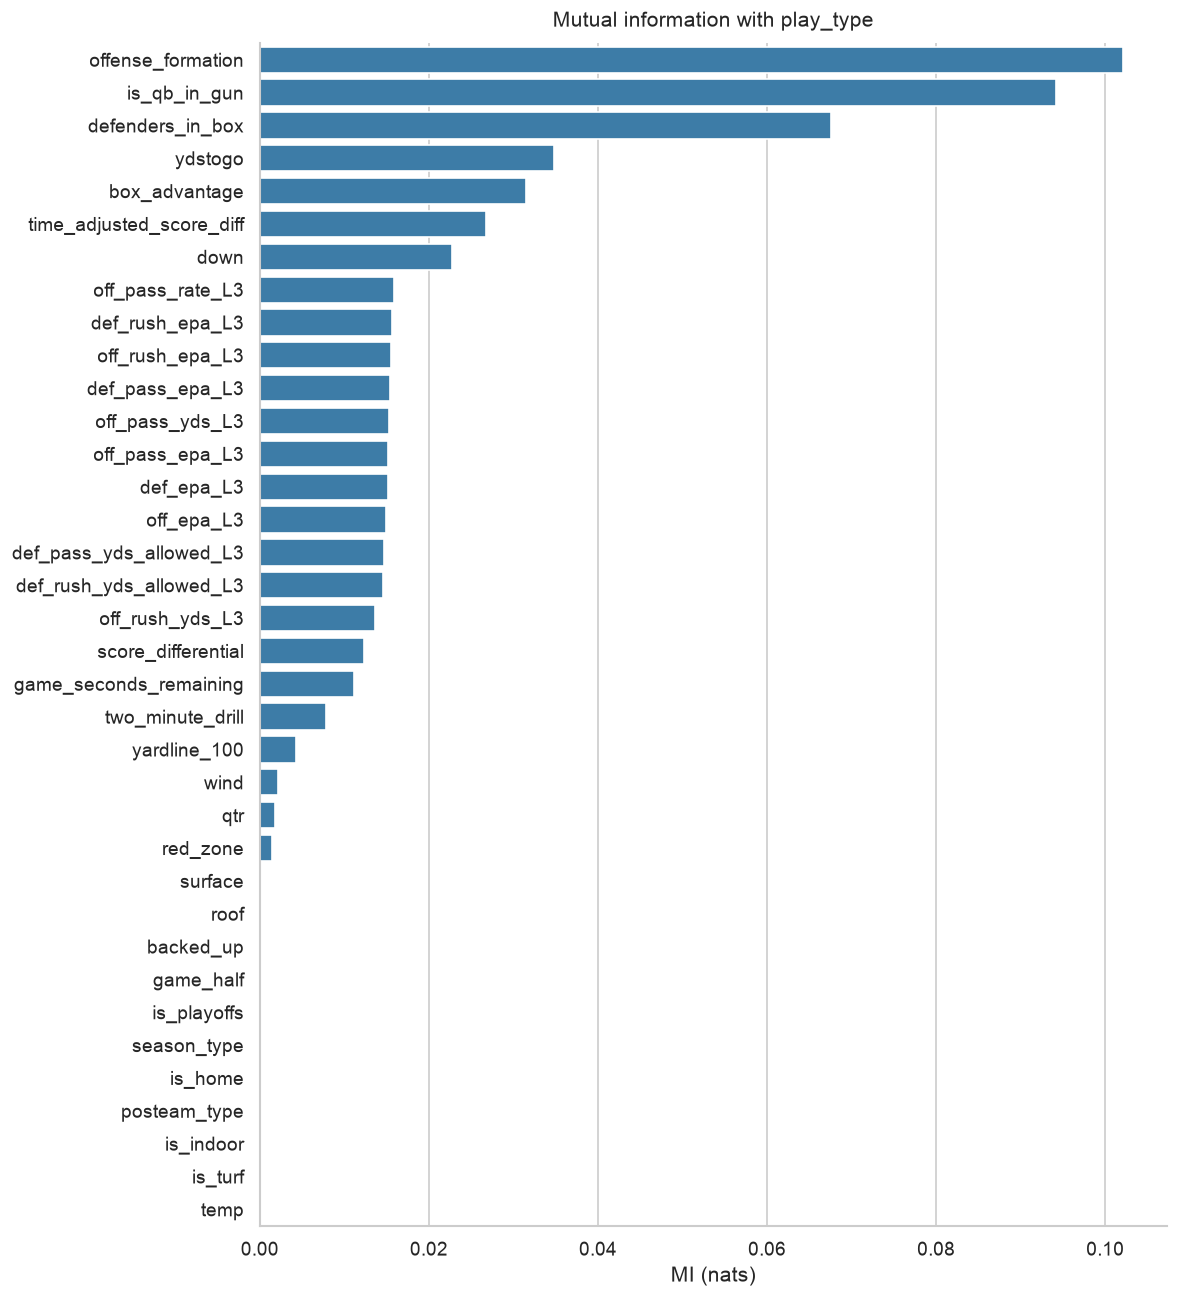

In [9]:
fig, ax = plt.subplots(figsize=(10, 11))
sns.barplot(data=mi_df, y="feature", x="mutual_info", color="#2c7fb8", ax=ax)
ax.set_title("Mutual information with play_type", pad=10)
ax.set_xlabel("MI (nats)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. ANOVA F-test — numerical features

`f_classif` tests whether each numeric feature's mean differs between the `pass`
and `run` classes. High F / low p = the feature separates the classes (under a
linear/Gaussian assumption — complementary to the non-parametric MI above).

In [10]:
from sklearn.feature_selection import f_classif

f_stat, f_p = f_classif(X_num_imp.values, y.values)
anova = pd.DataFrame({
    "feature": ALL_NUMERIC,
    "F_stat": f_stat,
    "p_value": f_p,
})
anova["significant"] = anova["p_value"] < 0.05
anova = anova.sort_values("F_stat", ascending=False).reset_index(drop=True)
print(f"Significant (p < 0.05): {anova['significant'].sum()} / {len(anova)}")
anova

Significant (p < 0.05): 25 / 30


,feature,F_stat,p_value,significant
0,is_qb_in_gun,62837.753872,0.000000e+00,True
1,defenders_in_box,33861.463355,0.000000e+00,True
2,box_advantage,13512.426232,0.000000e+00,True
3,down,11010.472961,0.000000e+00,True
4,time_adjusted_score_diff,8000.493361,0.000000e+00,True
5,score_differential,5860.238117,0.000000e+00,True
6,two_minute_drill,4151.399301,0.000000e+00,True
7,ydstogo,3822.916547,0.000000e+00,True
8,red_zone,817.685961,1.411693e-179,True
9,off_pass_rate_L3,806.320202,4.107469e-177,True


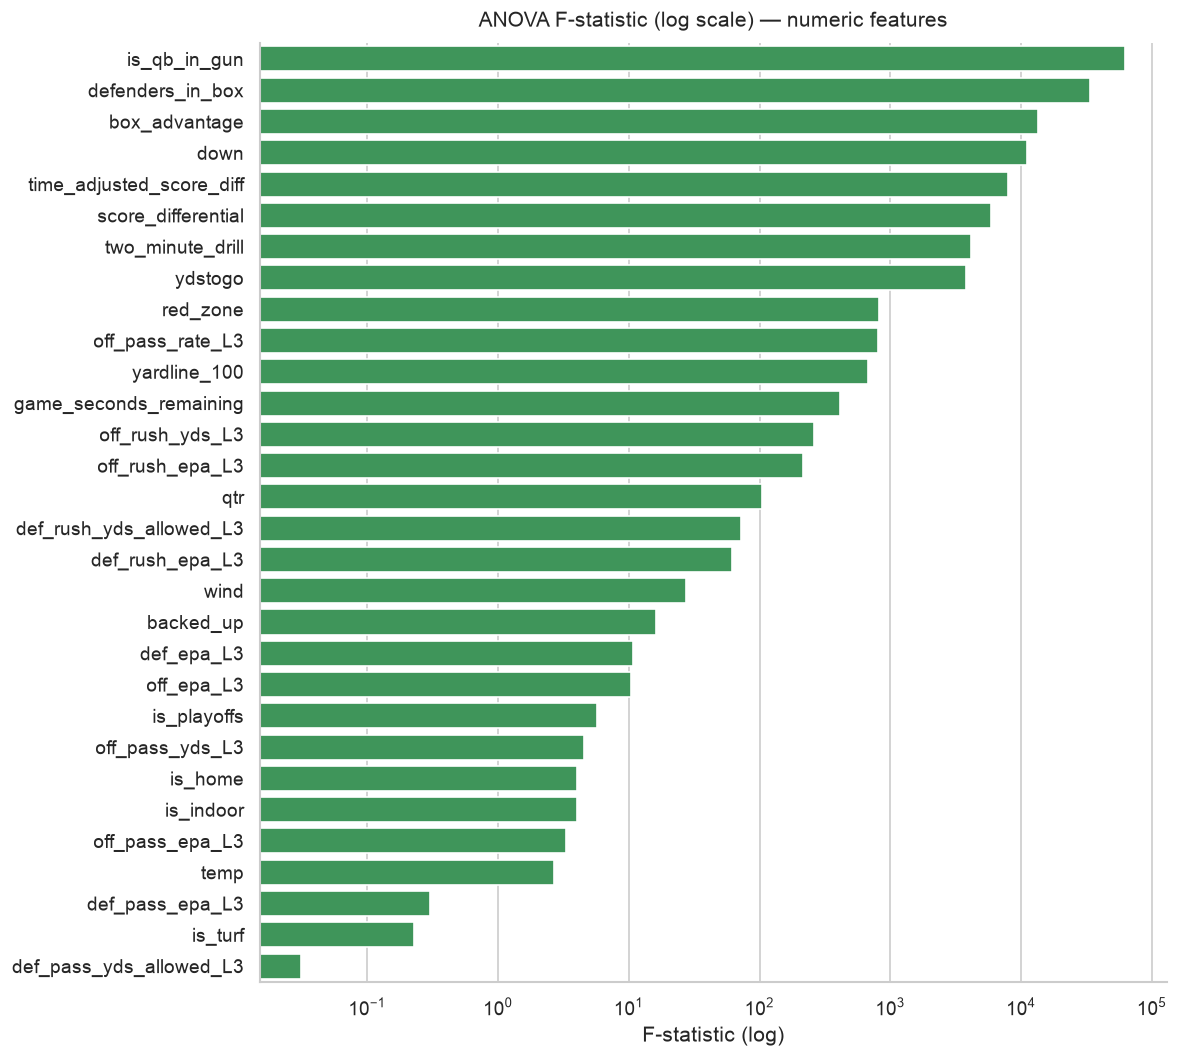

In [11]:
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=anova, y="feature", x="F_stat", color="#31a354", ax=ax)
ax.set_xscale("log")
ax.set_title("ANOVA F-statistic (log scale) — numeric features", pad=10)
ax.set_xlabel("F-statistic (log)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Chi-square test — categorical features

Tests independence between each categorical feature and `play_type` via a
contingency table. Low p = the feature and target are dependent (informative).
Screens the multi-level categoricals plus the binary/discrete flags in
`CHI2_FEATURES`. Cramér's V gives a 0–1 effect size (p-values are inflated at
this sample size, so rank by effect size).

In [12]:
from scipy.stats import chi2_contingency

def cramers_v(confusion):
    chi2 = chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

rows = []
for c in CHI2_FEATURES:
    table = pd.crosstab(df[c].astype(str), y)
    chi2, p, dof, _ = chi2_contingency(table)
    rows.append({
        "feature": c,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v(table.values),
        "n_levels": table.shape[0],
    })

chi2_df = pd.DataFrame(rows)
chi2_df["significant"] = chi2_df["p_value"] < 0.05
chi2_df = chi2_df.sort_values("cramers_v", ascending=False).reset_index(drop=True)
print(f"Significant (p < 0.05): {chi2_df['significant'].sum()} / {len(chi2_df)}")
chi2_df

Significant (p < 0.05): 12 / 12


,feature,chi2,p_value,dof,cramers_v,n_levels,significant
0,offense_formation,54130.113249,0.000000e+00,8,0.442597,9,True
1,is_qb_in_gun,51192.760014,0.000000e+00,1,0.430456,2,True
2,down,12080.781304,0.000000e+00,3,0.209081,4,True
3,two_minute_drill,4089.205554,0.000000e+00,1,0.121655,2,True
4,qtr,966.470019,6.588068e-208,4,0.059022,5,True
5,red_zone,814.970578,3.000719e-179,1,0.054289,2,True
6,surface,33.304103,2.323651e-05,7,0.009757,8,True
7,backed_up,16.207714,5.676250e-05,1,0.007432,2,True
8,roof,16.701727,8.139116e-04,3,0.007042,4,True
9,game_half,12.676374,1.767504e-03,2,0.006216,3,True


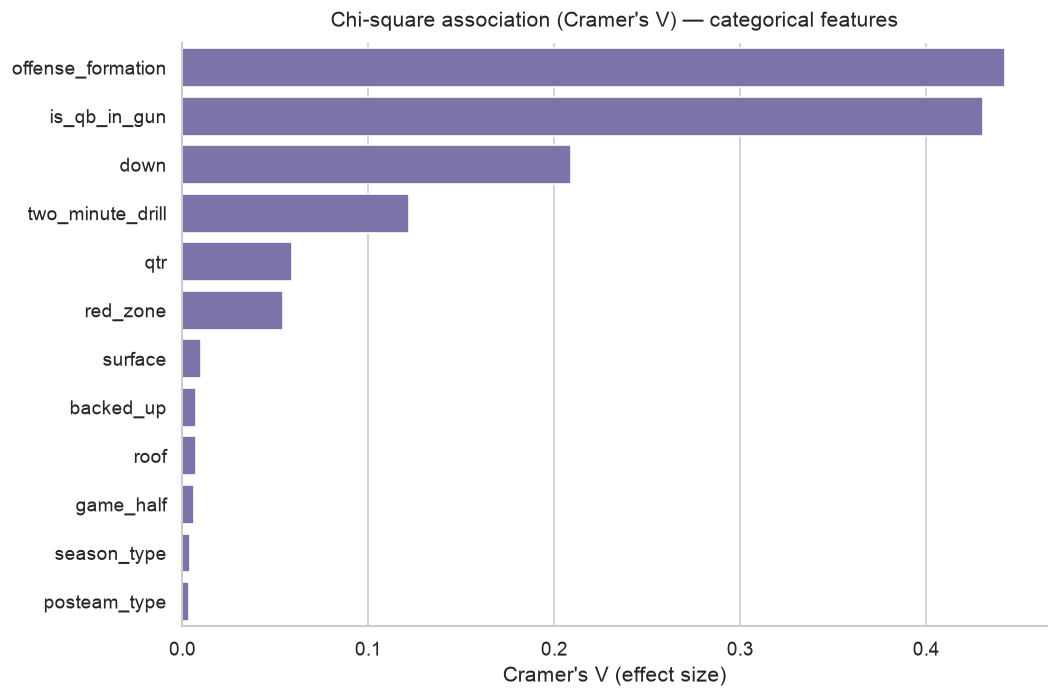

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=chi2_df, y="feature", x="cramers_v", color="#756bb1", ax=ax)
ax.set_title("Chi-square association (Cramer's V) — categorical features", pad=10)
ax.set_xlabel("Cramer's V (effect size)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Screening summary

Merge the per-method signals into one table for a combined read. Each method
answers a different question:

| Method | Captures | Applies to |
|---|---|---|
| Spearman + VIF | redundancy / multicollinearity | numeric |
| Mutual information | any dependency w/ target | all |
| ANOVA F-test | linear mean separation | numeric |
| Chi-square (Cramér's V) | categorical association | categorical |

Weak-everywhere features (low MI, low F, non-significant chi², high VIF among
correlated peers) are drop candidates for the downstream selection pipeline.

In [14]:
summary = mi_df.rename(columns={"mutual_info": "MI"}).copy()
summary = summary.merge(
    anova[["feature", "F_stat", "p_value"]].rename(
        columns={"F_stat": "anova_F", "p_value": "anova_p"}),
    on="feature", how="left",
)
summary = summary.merge(vif[["feature", "VIF"]], on="feature", how="left")
summary = summary.merge(
    chi2_df[["feature", "cramers_v", "p_value"]].rename(
        columns={"p_value": "chi2_p"}),
    on="feature", how="left",
)
summary = summary.sort_values("MI", ascending=False).reset_index(drop=True)
print("Combined screening summary (sorted by MI):")
summary

Combined screening summary (sorted by MI):


,feature,MI,anova_F,anova_p,VIF,cramers_v,chi2_p
0,offense_formation,1.021543e-01,NaN,NaN,NaN,0.442597,0.000000e+00
1,is_qb_in_gun,9.418752e-02,62837.753872,0.000000e+00,1.461630,0.430456,0.000000e+00
2,defenders_in_box,6.759616e-02,33861.463355,0.000000e+00,3.820722,NaN,NaN
3,ydstogo,3.481120e-02,3822.916547,0.000000e+00,1.340508,NaN,NaN
4,box_advantage,3.148142e-02,13512.426232,0.000000e+00,2.997896,NaN,NaN
5,time_adjusted_score_diff,2.671756e-02,8000.493361,0.000000e+00,11.041436,NaN,NaN
6,down,2.270850e-02,11010.472961,0.000000e+00,1.318842,0.209081,0.000000e+00
7,off_pass_rate_L3,1.581687e-02,806.320202,4.107469e-177,1.213447,NaN,NaN
8,def_rush_epa_L3,1.565983e-02,61.805778,3.804149e-15,5.951466,NaN,NaN
9,off_rush_epa_L3,1.554027e-02,215.287849,1.006113e-48,6.375307,NaN,NaN
